# New York Housing Prices — Multiple Linear Regression





## 1. Understanding the data

First we load the data and look at it to understand what we are working with.

In [1]:
# STEP 1: Import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
# Load the dataset (the CSV file must be in the same folder as this notebook)
df = pd.read_csv("NYHousing.csv")
# Show the first 5 rows
df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


# Data Understanding

In [2]:
# Check how many rows and columns there are
df.shape
# Check the column names, data types and counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 
 13  LONG_NAME         

In [3]:
df.describe()

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.000000,4801.000000,4801.000000,4801.000000,4801.000000
mean,2.356940e+06,3.356801,2.373861,2184.207862,40.714227,-73.941601
std,3.135525e+07,2.602315,1.946962,2377.140894,0.087676,0.101082
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639375,-73.987143
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726749,-73.949189
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771923,-73.870638
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


In [4]:
# Check for missing values
df.isnull().sum()



BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_ADDRESS                   0
ADMINISTRATIVE_AREA_LEVEL_2    0
LOCALITY                       0
SUBLOCALITY                    0
STREET_NAME                    0
LONG_NAME                      0
FORMATTED_ADDRESS              0
LATITUDE                       0
LONGITUDE                      0
dtype: int64

In [5]:
# Check for duplicates
df.duplicated().sum()

np.int64(214)

## 2. Initial visualizations of the original data



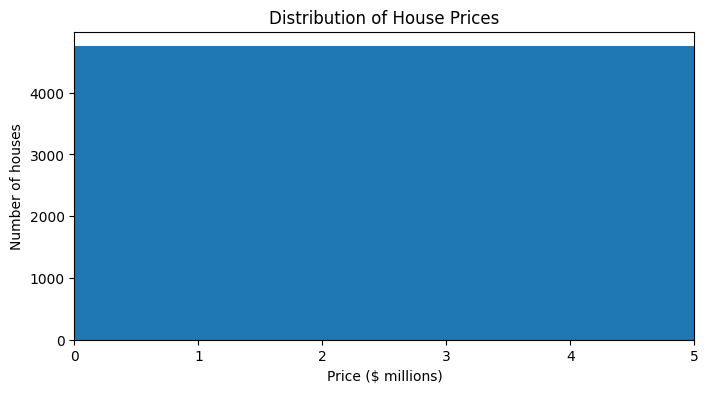

In [6]:
# Chart 1: how prices are spread out (in millions of dollars)
plt.figure(figsize=(8, 4))
plt.hist(df["PRICE"] / 1000000, bins=100)
plt.xlim(0, 5)   # only show up to $5m so the chart is readable
plt.title("Distribution of House Prices")
plt.xlabel("Price ($ millions)")
plt.ylabel("Number of houses")
plt.show()

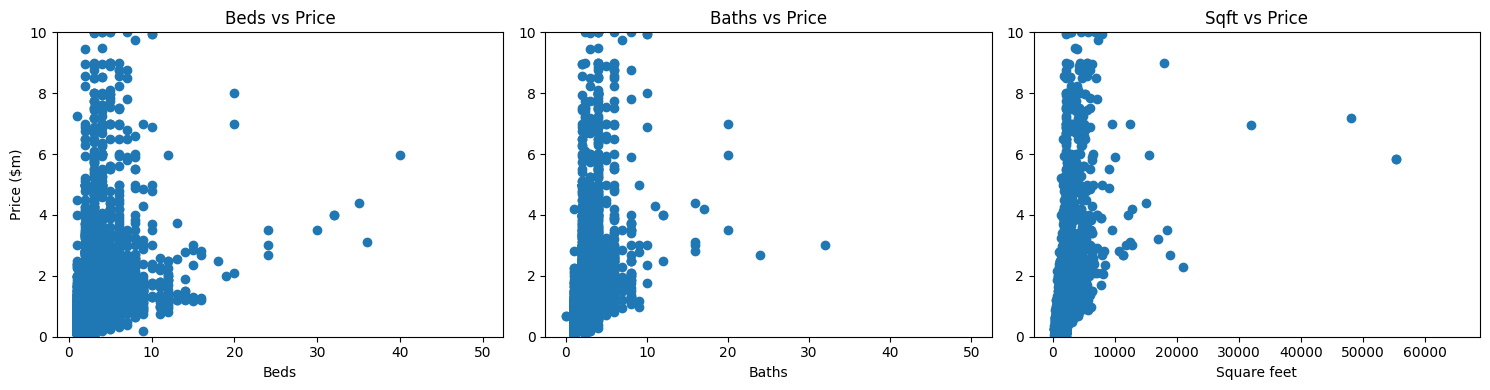

In [7]:
# Chart 2: each feature against price, to see if there is a relationship
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(df["BEDS"], df["PRICE"] / 1000000)
plt.title("Beds vs Price"); plt.xlabel("Beds"); plt.ylabel("Price ($m)"); plt.ylim(0, 10)

plt.subplot(1, 3, 2)
plt.scatter(df["BATH"], df["PRICE"] / 1000000)
plt.title("Baths vs Price"); plt.xlabel("Baths"); plt.ylim(0, 10)

plt.subplot(1, 3, 3)
plt.scatter(df["PROPERTYSQFT"], df["PRICE"] / 1000000)
plt.title("Sqft vs Price"); plt.xlabel("Square feet"); plt.ylim(0, 10)

plt.tight_layout()
plt.show()

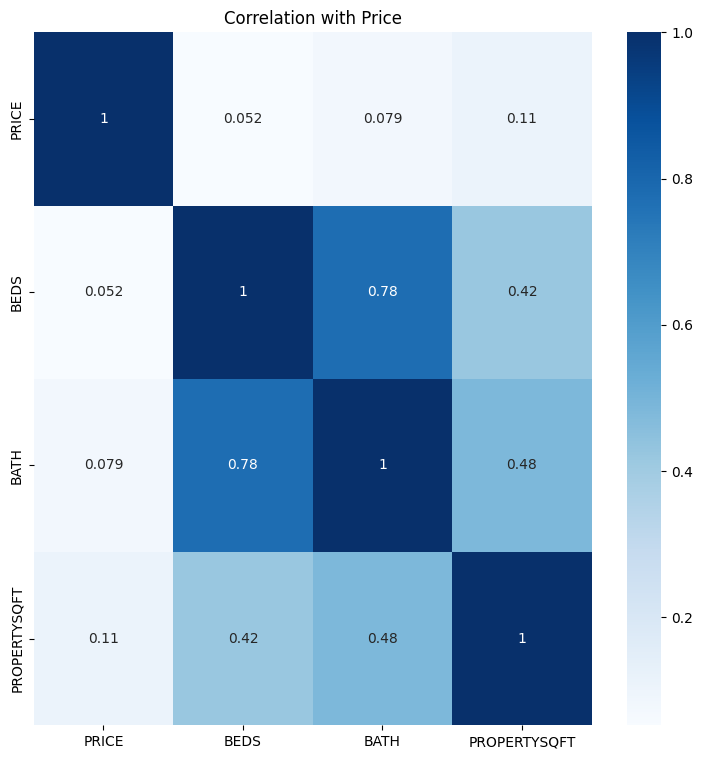

In [8]:
#  correlation heatmap 
plt.figure(figsize=(9, 9))
sns.heatmap(df[["PRICE", "BEDS", "BATH", "PROPERTYSQFT"]].corr(), annot=True, cmap="Blues")
plt.title("Correlation with Price")
plt.show()

## 3. Data preparation and feature engineering


In [9]:
data = df.copy()
# Remove duplicate rows
data = data.drop_duplicates()


In [10]:
# --- Feature engineering: create new useful columns ---

# 1) Take the log of price and size. They are very skewed, and log makes them
#    more even, which helps a linear model a lot.
data["LOG_PRICE"] = np.log(data["PRICE"])
data["LOG_SQFT"] = np.log(data["PROPERTYSQFT"])

# 2) Bathrooms per bedroom (a simple measure of how "luxury" a home is)
data["BATH_PER_BED"] = data["BATH"] / data["BEDS"].replace(0, 1)  # the replace avoids dividing by 0

data[["PRICE", "LOG_PRICE", "PROPERTYSQFT", "LOG_SQFT", "BATH_PER_BED"]].head()

,PRICE,LOG_PRICE,PROPERTYSQFT,LOG_SQFT,BATH_PER_BED
0,315000,12.660328,1400.0,7.244228,1.000000
1,195000000,19.088510,17545.0,9.772524,1.428571
2,260000,12.468437,2015.0,7.608374,0.500000
3,69000,11.141862,445.0,6.098074,0.333333
4,55000000,17.822844,14175.0,9.559235,0.339123


In [11]:
# 3) Clean up the location column.
#    The same borough is written in different ways, so we group them together.
borough_map = {
    "New York": "Manhattan", "New York County": "Manhattan", "Manhattan": "Manhattan",
    "Kings County": "Brooklyn", "Brooklyn": "Brooklyn", "Coney Island": "Brooklyn",
    "Queens County": "Queens", "Queens": "Queens", "Flushing": "Queens",
    "Richmond County": "Staten Island", "Staten Island": "Staten Island",
    "Bronx County": "Bronx", "The Bronx": "Bronx", "East Bronx": "Bronx", "Riverdale": "Bronx",
}
data["BOROUGH"] = data["SUBLOCALITY"].map(borough_map)

# Drop rows where the borough is unknown
data = data.dropna(subset=["BOROUGH"])

# 4) Clean up the property type (remove the words "for sale")
data["PROPERTY_TYPE"] = data["TYPE"].str.replace(" for sale", "")

print("Boroughs:", data["BOROUGH"].unique())
print("Property types:", data["PROPERTY_TYPE"].unique())

Boroughs: ['Manhattan' 'Staten Island' 'Brooklyn' 'Bronx' 'Queens']
Property types: ['Condo' 'House' 'Townhouse' 'Co-op' 'Multi-family home' 'For sale'
 'Contingent' 'Land' 'Foreclosure' 'Pending' 'Coming Soon' 'Mobile house'
 'Condop']


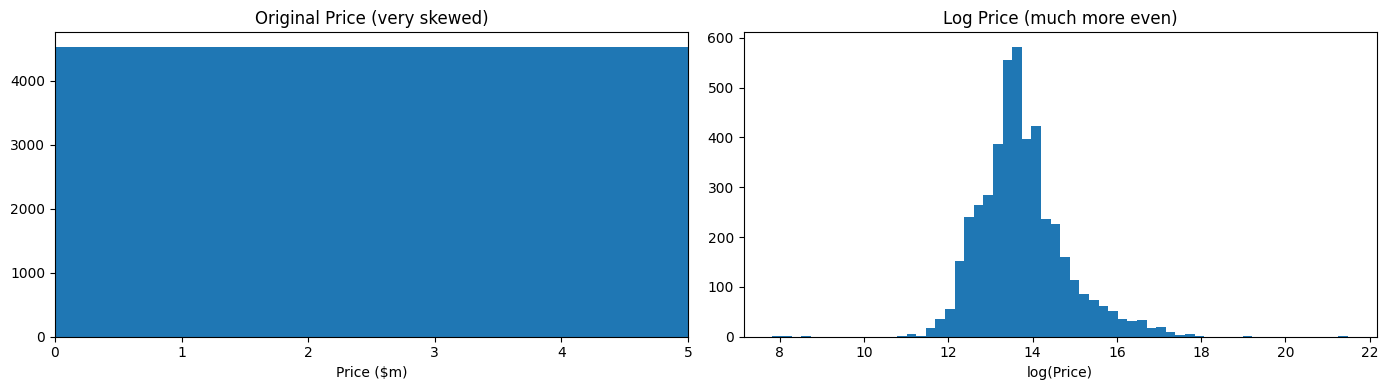

In [12]:
# Show why the log transform helps: price before and after
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.hist(data["PRICE"] / 1000000, bins=100)
plt.xlim(0, 5)
plt.title("Original Price (very skewed)")
plt.xlabel("Price ($m)")

plt.subplot(1, 2, 2)
plt.hist(data["LOG_PRICE"], bins=60)
plt.title("Log Price (much more even)")
plt.xlabel("log(Price)")

plt.tight_layout()
plt.show()

In [13]:
# Features Used
number_features = ["BEDS", "BATH", "LOG_SQFT", "BATH_PER_BED"]

borough_columns = pd.get_dummies(data["BOROUGH"], drop_first=True)
type_columns = pd.get_dummies(data["PROPERTY_TYPE"], prefix="TYPE", drop_first=True)

# Inserted all features together into one table
X = pd.concat([data[number_features], borough_columns, type_columns], axis=1)
X = X.astype(float)   # make sure every column is a number

# The target is the log of price
y = data["LOG_PRICE"]



## Train the model


In [14]:
# STEP 1: Split into training (80%) and test (20%) data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 2: Standardize the features (mean 0, standard deviation 1).
# We learn the scaling from the training data, then apply it to both.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 3: Create and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("The model is trained.")

The model is trained.


In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", round(model.intercept_, 3))
coefficients

Intercept: 13.745


,Feature,Coefficient
0,BEDS,-0.046484
1,BATH,0.243300
2,LOG_SQFT,0.382135
3,BATH_PER_BED,0.013154
4,Brooklyn,0.181545
5,Manhattan,0.484768
6,Queens,0.073141
7,Staten Island,0.012567
8,TYPE_Coming Soon,0.011796
9,TYPE_Condo,0.289493


## Predicting the price of a 5-bed, 5-bath, 350 sqft property



In [16]:
new_house = pd.DataFrame([{
    "BEDS": 5,
    "BATH": 5,
    "LOG_SQFT": np.log(350),     
    "BATH_PER_BED": 5 / 5,      
    "Manhattan": 1,             
    "TYPE_Condo": 1             
}])


new_house = new_house.reindex(columns=X.columns, fill_value=0)

# Scale it the same way as the training data, then predict
new_house_scaled = scaler.transform(new_house)
predicted_log_price = model.predict(new_house_scaled)[0]
predicted_price = np.exp(predicted_log_price)
print("Predicted price:", round(predicted_price, 2), "dollars")


Predicted price: 1094050.58 dollars


## Two performance-evaluation tests



In [17]:
# Predict on the test data
y_pred = model.predict(X_test_scaled)

# TEST 1: R-squared
r2 = r2_score(y_test, y_pred)
print("Test 1 - R-squared:", round(r2, 4))

# TEST 2: RMSE (root mean squared error), on the log scale
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test 2 - RMSE (log scale):", round(rmse, 4))



Test 1 - R-squared: 0.5959
Test 2 - RMSE (log scale): 0.6627


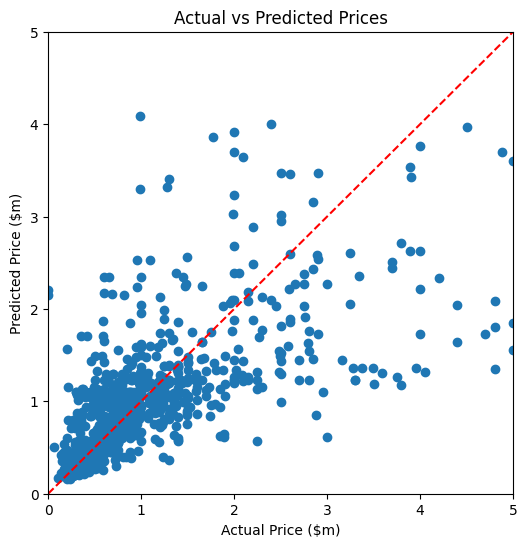

In [19]:
# Convert actual and predicted log prices back to dollars
actual_dollars = np.exp(y_test)
predicted_dollars = np.exp(y_pred)

# Chart: actual price vs predicted price
plt.figure(figsize=(6, 6))

plt.scatter(
    actual_dollars / 1000000,
    predicted_dollars / 1000000
)

# Perfect prediction line
plt.plot([0, 5], [0, 5], "r--")

plt.xlim(0, 5)
plt.ylim(0, 5)

plt.xlabel("Actual Price ($m)")
plt.ylabel("Predicted Price ($m)")
plt.title("Actual vs Predicted Prices")

plt.show()